## Setting environment up for Colab

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
base_path = Path('/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/week_1/sessions/')

This is a **demonstration notebook** — our goal is to observe, reflect, and prepare to perform similar steps in the next guided exercise using a different dataset and later in your projects.


# Week 1 – Session 3 - Part a: Dataset Exploration (Demonstration)

In this notebook, we will explore the structure and quality of a real-world misinformation dataset. This step is crucial before any modeling, as understanding data helps guide preprocessing, feature selection, and evaluation decisions.

### Objectives
By the end of this notebook, we will be able to:
- Inspect and interpret the structure of a labeled misinformation dataset.
- Perform:
  - Objective–Data Alignment Check: data has binary labels that work for classification setting
  - Sufficiency Assessment: need a minimum # of training samples per class for reliable training (class distribution of real vs. fake news)   
  - Quality Evaluation: look at variables in dataset; compute statistics to start identifying potential issues (outliers, missing values, low quality data) that will need to be handled in next “data cleaning” session


> 💡 *Think about what properties might distinguish fake news from real news, even before modeling. Can metadata or writing style give clues?*

## Libraries Used

We'll be using the following Python libraries throughout this notebook:

- **pandas**: For loading and manipulating tabular data.
- **matplotlib / seaborn**: For visualizing distributions and relationships in the dataset.
- **collections.Counter**: To count word frequencies efficiently.
- **nltk / re**: For basic text preprocessing and tokenization.
- **wordcloud** *(optional)*: To generate word clouds for visualizing common vocabulary.

If you're running this notebook for the first time, you may need to install some of these libraries using `!pip install pandas matplotlib seaborn nltk wordcloud`

> Note: We intentionally keep the dependencies minimal to focus on core data exploration and analysis.

In [4]:
# Install required libraries (run only once)
!pip install pandas matplotlib seaborn nltk wordcloud

## Download NLTK Resources

We need to download some basic tokenization and stopword resources from NLTK to support text analysis.

In [5]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Load the FakeNewsNet Dataset

We begin by loading four CSV files from the FakeNewsNet dataset, covering both real and fake articles from two dataset sources<!-- To avoid confusion with sources -->: *GossipCop* and *PolitiFact*.

Each dataset is labeled and tagged with its dataset source <!-- Changing references of source to dataset source --> before being combined into a single DataFrame for unified analysis.

In [6]:
# Load FakeNewsNet CSVs with Date

import pandas as pd
import os
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/copied-data/FakeNewsNet")
# Load and label all 4 datasets
datasets = {
    "gossipcop": pd.read_csv(DATA_DIR / Path("gossipcop.csv")),
    "politifact": pd.read_csv(DATA_DIR / Path("politifact.csv")),
}

# Add dataset_source and binary label columns
for name, df in datasets.items():
    datasets[name] = df

# Combine all into a single DataFrame
fnn_df = pd.concat(datasets.values(), ignore_index=True)

# Preview
print(f"Loaded {len(fnn_df):,} articles from GossipCop and PolitiFact")
fnn_df.sample(10)

Loaded 23,672 articles from GossipCop and PolitiFact


,id,title,article,url,date,dataset_source,label
13065,gossipcop-945217,TV Scoop Awards 2018: Vote for the Saddest Dea...,Small Austria shows big differences with US: W...,https://theworldnews.net/us-news/tv-scoop-awar...,NaN,gossipcop,0
23428,politifact261,CHIP Enrollment: June 2011 Data Snapshot,This data snapshot provides the latest data on...,http://www.kff.org/medicaid/upload/7642.pdf,NaN,politifact,0
23483,politifact736,The page you're looking for may have been move...,"We’re sorry, this site is currently experienci...",http://www.state.gov/r/pa/ei/bgn/5375.htm#econ,NaN,politifact,real
11626,gossipcop-916853,Meet the 18-year-old royal who’s taking the mo...,NaN,http://peoplemagazine.com.pk/meet-the-18-year-...,NaN,gossipcop,0
17696,gossipcop-875230,A Complete Timeline of Brad Pitt and Angelina ...,"All relationships have their ups and downs, es...",https://www.glamour.com/gallery/brad-pitt-and-...,2016-09-20,gossipcop,real
10241,gossipcop-917726,"Rebel Wilson Jokes That She, Too, Secretly Got...",NaN,https://www.longroom.com/discussion/915561/reb...,NaN,gossipcop,0
20325,gossipcop-885776,Brie Bella Get Surprising DNA Results in Total...,Brie Bella Get Surprising DNA Results in Total...,http://www.trueara.com/brie-bella-get-surprisi...,2017-10-10,gossipcop,0
7912,gossipcop-951347,"Lin-Manuel Miranda, RuPaul, Tiffany Haddish an...","It’s Emmy nominations morning, and Hollywood i...",https://www.latimes.com/entertainment/tv/showt...,2018-07-12,gossipcop,0
20281,gossipcop-886107,Jessie James Decker Gets Hot and Bothered Watc...,Jessie James Decker Gets Hot and Bothered Watc...,http://www.trueara.com/jessie-james-decker-get...,2017-10-11,gossipcop,real
3473,gossipcop-7364517390,Actor Terry Crews: I was sexually assaulted by...,NaN,www.theguardian.com/film/2017/oct/11/actor-ter...,2017-10-11,gossipcop,1


## Modularity

> 📝: This function will be placed into `src`

It is good engineering practice to encapsulate reusable components into functions, that way you can don't need to rewrite those components from scratch each time.

Whenever you see the note above, "📝", we will be creating content that will go into the `src` directory. As we go through this project, we will add functions into the relevant files in the `src` directory, such that by the end, all our components can be grouped into a single library and deployed modularly.

We will start by creating a dataloader function below:

In [ ]:
import os
from pathlib import Path
import pandas as pd

def load_fakenewsnet_data(
        raw_data_dir, datasets=None, verbose=False
    ):
    """
    Load and combine the FakeNewsNet datasets (GossipCop and PolitiFact).

    Args:
        raw_data_dir (str or Path): Directory containing the CSV files
        [Optional] datasets (dict): Dictionary storing the name (str or Path) of the CSV files storing each component of the dataset
            When not provided, the csv files are assumed to be:
            - gossipcop.csv
            - politifact.csv

    Returns:
        pd.DataFrame: Combined dataframe with columns ['article', 'dataset_source', 'label', ...]
    """

    if datasets is None:
        datasets = {
            "gossipcop": Path("gossipcop.csv"),
            "politifact": Path("politifact.csv"),
        }

    datasets_df = {}

    for name, path in datasets.items():
        df = pd.read_csv(Path(raw_data_dir) / Path(path))
        datasets_df[name] = df

    fnn_df = pd.concat(datasets_df.values(), ignore_index=True)
    if verbose:
        print(f"Loaded {len(fnn_df):,} articles from GossipCop and PolitiFact")
    return fnn_df

The next step is to package this function into our src directory. For reference, it will be placed into the /src/misinformation_detection/data/data_loader.py file.

After that, we need to add the function into the list of exposed functions in the `/src/misinformation_detection/data/__init__.py` by adding the line

``` python
from .data_loader import load_fakenewsnet_data
```  

## [💎 Additional Credit] Pytest

`pytest` is a robust and highly popular Python library used for **writing simple, scalable, and effective test cases**. It's the standard tool for automating code testing in the Python ecosystem.

---

### Comprehensive Testing Suite (Additional Credit)

While there is **no minimum testing requirement** for this course, implementing any form of testing using Pytest will earn **Additional Credit**.

A truly **Comprehensive Testing Suite** extends this concept by validating the AI project across different logical layers:

1.  **Unit Tests:** Testing individual components like data loading functions, pre-processing steps, or single methods within your model class.
2.  **Integration Tests:** Validating that two or more parts of the pipeline work correctly together (e.g., ensuring the pre-processor correctly feeds data to the model).
3.  **End-to-End (E2E) Tests:** Simulating a full run of the AI pipeline—from raw input to final output—to confirm the entire system operates as expected.

Building a Comprehensive Testing Suite demonstrates significant initiative and a commitment to professional software development and MLOps principles, which is why it qualifies for the **Additional Credit** designation.

---

All content explaining how `pytest` works through building tests for our developed library will be in the `test` folder

## Dataset Overview

Let's inspect the structure of the dataset, check for missing values and duplicates, and understand how the classes (fake vs. real) are distributed.

We'll also visualize key aspects to make patterns and potential issues more apparent.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Show dataset info
fnn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23672 entries, 0 to 23671
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              23672 non-null  object
 1   title           23672 non-null  object
 2   article         16428 non-null  object
 3   url             23334 non-null  object
 4   date            11498 non-null  object
 5   dataset_source  23672 non-null  object
 6   label           23672 non-null  object
dtypes: object(7)
memory usage: 1.3+ MB


In [9]:
# Preview sample rows
fnn_df.head()

,id,title,article,url,date,dataset_source,label
0,gossipcop-2493749932,Did Miley Cyrus and Liam Hemsworth secretly ge...,Congratulations might be in order for Miley Cy...,www.dailymail.co.uk/tvshowbiz/article-5874213/...,2018-06-22,gossipcop,fake
1,gossipcop-4580247171,Paris Jackson & Cara Delevingne Enjoy Night Ou...,NaN,hollywoodlife.com/2018/05/05/paris-jackson-car...,NaN,gossipcop,fake
2,gossipcop-941805037,Celebrities Join Tax March in Protest of Donal...,Thousands are taking the streets to protest Pr...,variety.com/2017/biz/news/tax-march-donald-tru...,2017-04-15,gossipcop,fake
3,gossipcop-2547891536,Cindy Crawford's daughter Kaia Gerber wears a ...,We'd venture to say that Cindy Crawford's daug...,www.dailymail.co.uk/femail/article-3499192/Do-...,2016-03-18,gossipcop,fake
4,gossipcop-5476631226,Full List of 2018 Oscar Nominations – Variety,Oscar nominations for the 90th annual awards w...,variety.com/2018/film/news/list-2018-oscar-nom...,2018-01-23,gossipcop,fake


#Quality Assessment

## Initial Objective-Data Alignment Check

Before proceeding, we confirm that our dataset contains the necessary components to achieve our objective: *binary classification of an article as real or fake*

The core columns required are:
- **Target Variable**: The 'label' column (fake/real) is present and matches our objective.
- **Input Text**: The 'article' and 'title' columns provide the textual data for modeling.

Additionally, the dataset provides metadata columns that could help assist in the task
- **Metadata**: 'dataset_source', 'url', and 'date' provide auxiliary features that can inform model predictions (e.g., source credibility, temporal trends).

Since all critical components are available, we can proceed to package the data loading process and continue with cleaning and transformation.

## Missing Values

Missing data can introduce bias or reduce model performance if not handled properly. Below, we count and visualize the number of missing values in each column.

If no missing values are found, we’ll note that the dataset is complete. Otherwise, we’ll use this information to guide our cleaning strategy later.

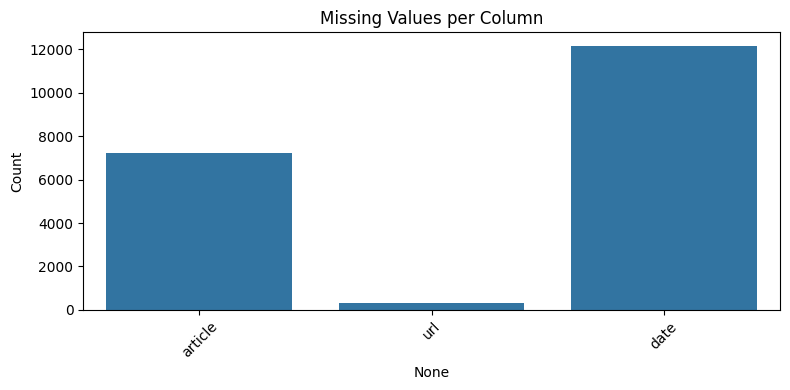

In [10]:
# Count and visualize missing values
missing_counts = fnn_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

if not missing_counts.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_counts.index, y=missing_counts.values)
    plt.title("Missing Values per Column")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

No missing values in the label.

In [11]:
# copy dataset to avoid cluttering
fnn_df_tmp = fnn_df.copy()
fnn_df_tmp['article_missing'] = fnn_df_tmp['article'].isnull()
fnn_df_tmp['date_missing'] = fnn_df_tmp['date'].isnull()
fnn_df_tmp['title_missing'] = fnn_df_tmp['title'].isnull()

In [12]:
# fnn_df_tmp[['dataset_source', 'article_missing']].value_counts()
fnn_df_tmp[['dataset_source', 'article_missing']].value_counts(normalize=True)

dataset_source  article_missing
gossipcop       False              0.675989
                True               0.278008
politifact      True               0.028008
                False              0.017996
Name: proportion, dtype: float64

In [13]:
# fnn_df_tmp[['dataset_source', 'article_missing']].value_counts()
fnn_df_tmp[['dataset_source', 'article_missing', 'title_missing']].value_counts(normalize=True)

dataset_source  article_missing  title_missing
gossipcop       False            False            0.675989
                True             False            0.278008
politifact      True             False            0.028008
                False            False            0.017996
Name: proportion, dtype: float64

## Outliers: Article Length Summary & Distribution

We summarize and visualize the article lengths to understand how much textual content each entry provides.

This includes:
- Descriptive statistics (min, max, mean, median)
- Histogram of the distribution
- Vertical lines to highlight min, mean, and max values

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Drop rows with missing 'article' before computing length
fnn_df_nonnull = fnn_df[fnn_df["article"].notnull()].copy()
fnn_df_nonnull["article_length"] = fnn_df_nonnull["article"].astype(str).apply(len)

In [16]:
# Summary statistics
length_stats = fnn_df_nonnull["article_length"].describe()
min_len = int(length_stats["min"])
max_len = int(length_stats["max"])
mean_len = length_stats["mean"]

print(length_stats)
print(f"\nMin length: {min_len} characters")
print(f"Max length: {max_len} characters")
print(f"Mean length: {mean_len:.2f} characters")

count     16428.000000
mean       4051.796932
std        8468.575446
min          21.000000
25%        1215.750000
50%        2195.000000
75%        3617.250000
max      337667.000000
Name: article_length, dtype: float64

Min length: 21 characters
Max length: 337667 characters
Mean length: 4051.80 characters


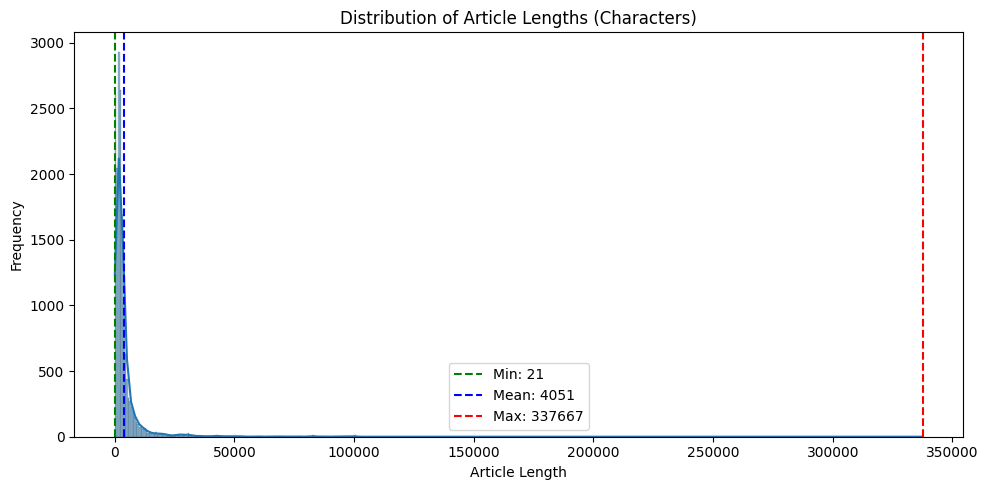

In [17]:
# Histogram with markers
plt.figure(figsize=(10, 5))
sns.histplot(fnn_df_nonnull["article_length"], bins=500, kde=True)
plt.axvline(min_len, color='green', linestyle='--', label=f"Min: {min_len}")
plt.axvline(mean_len, color='blue', linestyle='--', label=f"Mean: {int(mean_len)}")
plt.axvline(max_len, color='red', linestyle='--', label=f"Max: {max_len}")
plt.title("Distribution of Article Lengths (Characters)")
plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Potential outliers: Very short texts

In [18]:
fnn_df_nonnull[fnn_df_nonnull["article_length"] < 30]

,id,title,article,url,date,dataset_source,label,article_length
698,gossipcop-8586044284,"Keith Urban Walks out on Nicole Kidman After ""...","© 1990-2025 by IMDb.com, Inc.",www.imdb.com/news/ni61997245,NaN,gossipcop,fake,29
710,gossipcop-6044982799,Jerry O'Connell,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/name/nm0005278/,NaN,gossipcop,1,29
949,gossipcop-281278607,Sam Asghari - News,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/name/nm9001021/news,NaN,gossipcop,1,29
1355,gossipcop-6431500502,The Truth About Jennifer Aniston and Justin Th...,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/news/ni61972138,NaN,gossipcop,fake,29
1451,gossipcop-9520738949,Kevin Costner,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/name/nm0000126/awards,NaN,gossipcop,fake,29
1540,gossipcop-8560506152,The Next Great Female Movie/TV Stars,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/list/ls073256529/,NaN,gossipcop,1,29
1748,gossipcop-9191997037,Kanye West Shares Text Message With Caitlyn Je...,There are no items to show.,news.google.com/stories/CAAqfggKInhDQklTVkRvSm...,NaN,gossipcop,fake,27
1844,gossipcop-2710044770,Kendall Jenner,"© 1990-2025 by IMDb.com, Inc.",www.imdb.com/name/nm2832525/,NaN,gossipcop,fake,29
2208,gossipcop-8230458539,Kanye West's Ye is enjoyable,There are no items to show.,news.google.com/stories/CAAqYQgKIltDQklTUGpvSm...,NaN,gossipcop,1,27
2791,gossipcop-647321286,Google News,There are no items to show.,news.google.com/stories/CAAqOQgKIjNDQklTSURvSm...,NaN,gossipcop,fake,27


Some of these very short texts are actually just stating that there is no article - so we should remove them.

### Potential outliers: very long texts

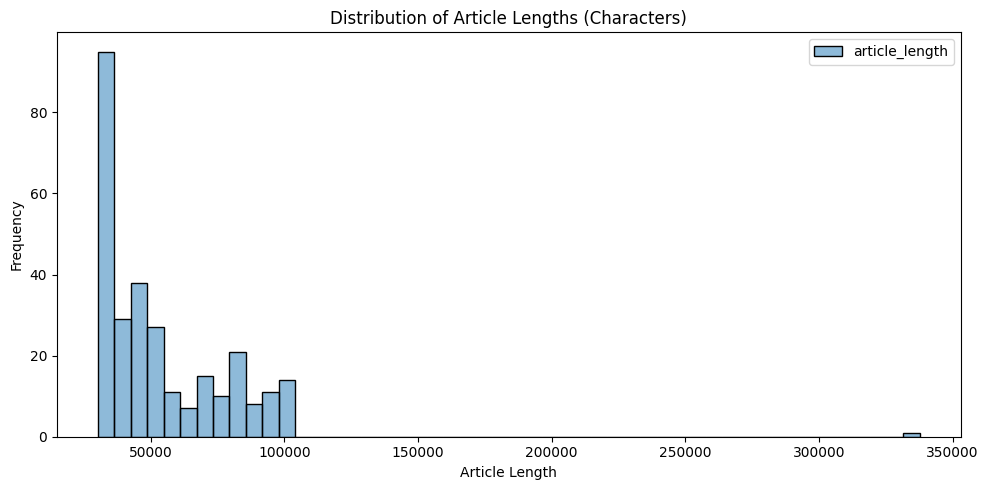

In [19]:
# Histogram of very long texts
plt.figure(figsize=(10, 5))
sns.histplot(fnn_df_nonnull[fnn_df_nonnull["article_length"]>30_000][["article_length"]], bins=50)
plt.title("Distribution of Article Lengths (Characters)")
plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [20]:
print(fnn_df_nonnull[fnn_df_nonnull["article_length"] > 200_000].iloc[0]["article"])



Evil Queen





Enchanted Forest Character

Biographical Information

Evil self:
Serum Queen


Wish Realm self:
Wish Evil Queen


Gender:
Female


Status:
Alive


Birthdate:
February 1[1]


Home:
United RealmsRoni's (formerly)Tiana's Palace (formerly)Resistance camp (formerly)Her house (formerly)Her palace (formerly)Summer Palace (formerly)Her manor (formerly)King Xavier's castle (formerly)


Occupation:
Bartender at Roni's (formerly)Mayor of Storybrooke (formerly)


Relatives:
See "Family"


Pets:
Rocinante †



Physical Description

Species:
HumanCecaelia (briefly)Rat (briefly)


Hair color:
BrownBlack (formerly)


Eye color:
Brown



Show Information

Portrayed by:
Lana Parrilla (adult)Ava Acres (young)


First appearance:
"Pilot"


Latest appearance:
"Leaving Storybrooke"


Relevant Pages
GALLERY




Regina Mills





Storybrooke Character

Biographical Information

Evil self:
Serum Queen


Wish Realm self:
Wish Evil Queen


Gender:
Female


Status:
Alive


Birthdate:
February 1[

Alone by its length, this is an exceptional text. We propose to delete it, possibly also the other ones with exceptional length.

## Integrity: Labels

Let's take a look at the labels in our dataset

In [21]:
print(fnn_df["label"].unique())

['fake' '1' '0' 'real']


In [22]:
fnn_df["label"].value_counts()

,count
label,
real,15122
fake,4984
0,2660
1,906


As we can see, the labels are inconsistent. and need to be fixed such that our labels are either `['0', '1']` or `['fake', 'real']` but not a combination of both. We will stick to the latter

In [23]:
fnn_df['label'] = fnn_df['label'].replace({'0': 'real', '1': 'fake'}) # 'label' is 0/1
print(fnn_df["label"].unique())

['fake' 'real']


## Uniqueness / Duplicates
We check for duplicate entries that might artificially inflate the size of our dataset or bias the model. We do that separately for the full set of attributes, and for the attributes `title` and `article` which we might use as basis for our prediction.

In [24]:
# Print number of duplicate entries
duplicate_entries_full = fnn_df[fnn_df.duplicated(keep=False)]
print(f"Duplicate entries (all attributes): {len(duplicate_entries_full)}")

Duplicate entries (all attributes): 807


In [25]:
# Print number of duplicate entries
duplicate_entries = fnn_df[fnn_df.duplicated(subset=["title", "article"], keep=False)]
print(f"Duplicate entries (based on title and article): {len(duplicate_entries)}")


Duplicate entries (based on title and article): 2787


Let's look at the full records of some duplicates on the title and article values:

In [26]:
ta_counts = pd.DataFrame(fnn_df[["title", "article"]].value_counts())
ta_counts.reset_index(inplace=True)
ta_counts[:3]

,title,article,count
0,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,11
1,- USweekly,Unprecedented Economic Boom\n\nBefore the Chin...,9
2,Sofia Richie,American model and media personality (born 199...,8


In [27]:
ta_counts = pd.DataFrame(fnn_df[["title", "article"]].value_counts())
ta_counts.reset_index(inplace=True)
ta_counts[:3]

,title,article,count
0,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,11
1,- USweekly,Unprecedented Economic Boom\n\nBefore the Chin...,9
2,Sofia Richie,American model and media personality (born 199...,8


In [28]:
fnn_df[ fnn_df["article"] == ta_counts.iloc[0]["article"] ]

,id,title,article,url,date,dataset_source,label
7245,gossipcop-882983,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
7795,gossipcop-940098,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
8203,gossipcop-955948,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
9025,gossipcop-920121,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
10854,gossipcop-872891,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
11038,gossipcop-875412,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
13930,gossipcop-920652,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
15305,gossipcop-859517,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
15451,gossipcop-890620,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real
17168,gossipcop-887710,This Is Us: Sterling K Brown Tells Us Why Rand...,(Warning: This post contains spoilers for the ...,https://www.thewrap.com/this-is-us-everything-...,2019-01-16,gossipcop,real


Here, all labels are the same. But this is not the case for all duplicates on title and article:

In [29]:
fnn_df[ fnn_df["article"] == ta_counts.iloc[2]["article"] ]

,id,title,article,url,date,dataset_source,label
831,gossipcop-6443705269,Sofia Richie,American model and media personality (born 199...,en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,fake
903,gossipcop-7324296383,Sofia Richie,American model and media personality (born 199...,en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,fake
3177,gossipcop-8098438027,Sofia Richie,American model and media personality (born 199...,en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,fake
4383,gossipcop-5797352043,Sofia Richie,American model and media personality (born 199...,en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,fake
5930,gossipcop-941659,Sofia Richie,American model and media personality (born 199...,https://en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,real
18206,gossipcop-881465,Sofia Richie,American model and media personality (born 199...,https://en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,real
21947,gossipcop-914648,Sofia Richie,American model and media personality (born 199...,https://en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,real
22271,gossipcop-6443705269,Sofia Richie,American model and media personality (born 199...,en.wikipedia.org/wiki/Sofia_Richie,NaN,gossipcop,fake


Here we see that there are different labels for records with the exact same title and article text. This needs to be investigated.

## Imbalance: Class Label Distribution

We visualize the distribution of news labels (`fake` vs. `real`) to understand class balance. Imbalanced datasets can lead to biased models, so this is an important diagnostic step.

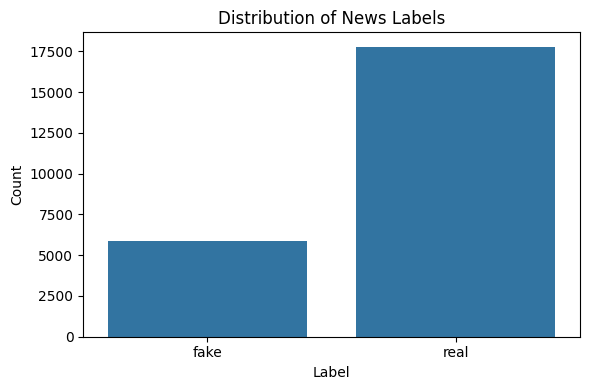

In [30]:
# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=fnn_df, x='label', order=['fake', 'real'])
plt.title("Distribution of News Labels")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

## Alignment
Let's summarize the match between our intended data use, and the data we actually have:
* **Missing features**: there are clearly some missings, and it might be worth checking the data extraction. But there's no evidence in the data that this might cause problems.
* **History**: We didn't check the distribution over time - for now, we simply assume that the real and fake data does not change over time.
***Hint***: You might of course challenge this assumption! GenAI models get better over time, etc. But since we document it, we can discuss.
* **Granularity**: We have a label per record (article), which seems appropriate.
* **Population mismatch**: For now we assume this is a representative subset. Again, in practice, you'll have to argue for it (stating e.g., *"we took all data from tool XYZ of the years ...."*)
* **Label issues**: We fixed a technical issue. Otherwise we assume the information in the label is correct.

# Sufficiency Assessment

We now assess whether this dataset is **sufficient** for training a misinformation detection model. This includes checking:

- Whether there is enough data overall
- Balance between `fake` and `real` labels
- Coverage across sources (`gossipcop`, `politifact`)
- Distribution of article lengths (already analyzed)

Sufficiency does not mean perfection — it means we have *enough usable data* to proceed with modeling and evaluation.

> **Note on Sufficiency:** Evaluating data sufficiency is not always prescriptive and is highly dependent on the **specific domain and business objective**. This assessment often requires **domain expertise** to determine what constitutes a meaningful sample size, relevant metadata, and an acceptable level of data noise for the application at hand.

## Summary: Sufficiency & Quality Assessment

### Sufficiency

We begin by assessing whether we have **enough usable and diverse data** to build a misinformation detection model:

- **Total articles**: 23,672
- **Label balance**:
  - Real: 17,782 (75%)
  - Fake: 5,890 (25%)
  → This class imbalance (~3:1) may lead models to overpredict "real" without proper handling (e.g., resampling, weighting).
  
- **Source coverage**:
  - GossipCop: 22,583 articles
  - PolitiFact: 1,089 articles
  → Heavily skewed toward GossipCop, meaning models may overfit to its writing style or source-specific patterns.

- **Per-source label mix**:
  - GossipCop: Mostly real
  - PolitiFact: Fairly balanced
  → This discrepancy can also influence model bias and should be monitored in downstream evaluation.

### Quality

We next assess whether the content and metadata are **reliable, complete, and clean**:

- **Missing article content**: 2,828 rows (must be removed)
- **Very short articles (<250 chars)**: 1197 (likely low quality or missing — consider filtering or flagging)
- **Extremely long articles (>30,000 chars)**: 287 (possible HTML dumps or concatenations — review or truncate)
- **Duplicate articles (by `title` + `article`)**: 1,605 (deduplication recommended)
- **Missing metadata**:
  - `title`: none missing
  - `source`: none missing
  - `date`: 12,174 missing (may limit temporal modeling or trend analysis)

---

### Takeaway

This dataset is **sufficient in size** (note again that size sufficiency is not all what matters, and domain expertise is essential to fully assess the sufficiency of a dataset), but **imbalanced and noisy**:
- You will need to clean and filter it before use.
- Imbalances across **label** and **dataset source** (GossipCop vs. PolitiFact) should be handled carefully.
- Missing values, outliers, and duplicates must be cleaned to avoid learning spurious correlations.

All these issues will be addressed in the next notebook on **data cleaning and feature preparation**.